# Compresión de Imágenes usando teselas de Voronoi

Autor: Thanos Drossos

Clase: Análisis Exploratorio de Datos

A continuación, se describe el método propuesto para comprimir la imagen El Astronomo utilizando centroides y la teselación de Voronoi. Este enfoque se basa en el algoritmo k-means en un espacio de 5 dimensiones, combinando la posición espacial y el color de los píxeles para lograr una representación comprimida de la imagen.

---

## Funcionamiento del Método

El método sigue una serie de pasos bien definidos para transformar la imagen original en una versión comprimida:

1. **Preparación de Datos**:
   - La imagen se carga y convierte al formato RGB.
   - Para cada píxel, se crea un vector de 5 dimensiones que incluye:
     - Coordenadas espaciales normalizadas: $(\frac{x}{\text{ancho}}, \frac{y}{\text{alto}})$.
     - Valores de color normalizados: $ (\frac{R}{255}, \frac{G}{255}, \frac{B}{255})$.
   - La normalización asegura que las posiciones y los colores tengan un peso equilibrado en el proceso.

2. **Agrupamiento con K-Means**:
   - Se aplica el algoritmo k-means a los vectores de 5 dimensiones para identificar **k centroides**. Cada centroide representa una posición promedio y un color promedio de un grupo de píxeles.
   - El objetivo de k-means es minimizar la suma de las distancias cuadráticas entre los píxeles y sus centroides asignados.

3. **Teselación de Voronoi**:
   - Usando las posiciones espaciales $(x, y)$ de los centroides, se divide la imagen en **celdas de Voronoi**. Cada celda agrupa los píxeles más cercanos a un centroide en términos de distancia espacial.
   - A cada píxel dentro de una celda se le asigna el color del centroide correspondiente, generando la imagen comprimida.

4. **Reconstrucción**:
   - La imagen reconstruida consiste en regiones uniformes definidas por las celdas de Voronoi, coloreadas según los centroides. Esto reduce la cantidad de datos necesarios para representar la imagen.

---

## Distancia Utilizada

El método emplea diferentes medidas de distancia en distintas etapas:

- **Durante el Agrupamiento (K-Means)**:
  - Se utiliza la **distancia euclidiana en el espacio de 5 dimensiones**. Esta distancia considera tanto la posición (\(x, y\)) como el color (\(R, G, B\)) de los píxeles para determinar la similitud con los centroides.

- **Durante la Teselación de Voronoi**:
  - Se emplea la **distancia euclidiana en el espacio 2D**, basada únicamente en las coordenadas (\(x, y\)). Esto garantiza que las celdas sean regiones contiguas en la imagen.

- **Para Evaluar la Calidad**:
  - Se calcula el **Error Cuadrático Medio (MSE)** para medir la diferencia entre la imagen original y la reconstruida:
    $
    \text{MSE} = \frac{1}{\text{altura} \times \text{ancho} \times 3} \sum (\text{original} - \text{reconstruida})^2
    $

---

## Cálculo de la Tasa de Compresión y la Calidad

### Tasa de Compresión
La tasa de compresión mide cuánto se reduce el tamaño de la imagen original al representarla con centroides:

- **Tamaño de la Imagen Original**:
  - Una imagen RGB de 8 bits por canal ocupa $ \text{altura} \times \text{ancho} \times 3 $ bytes.

- **Tamaño de la Imagen Comprimida**:
  - Se representan **k centroides**, cada uno con:
    - 2 floats para la posición $(x, y)$.
    - 3 bytes para el color $(R, G, B)$.
  - Si cada float usa 4 bytes, un centroide ocupa 11 bytes.
  - El tamaño comprimido es $ k \times 11 $ bytes.

- **Fórmula de la Tasa de Compresión**:
  $
  \text{Tasa de Compresión} = \frac{\text{Tamaño Original}}{\text{Tamaño Comprimido}} = \frac{\text{altura} \times \text{ancho} \times 3}{k \times 11}
  $

### Calidad (MSE)
La calidad se evalúa con el MSE, donde un valor bajo indica mayor similitud entre la imagen original y la reconstruida.


Processing k=10...
MSE for k=10: 1728.42
Compression ratio for k=10: 7149.38


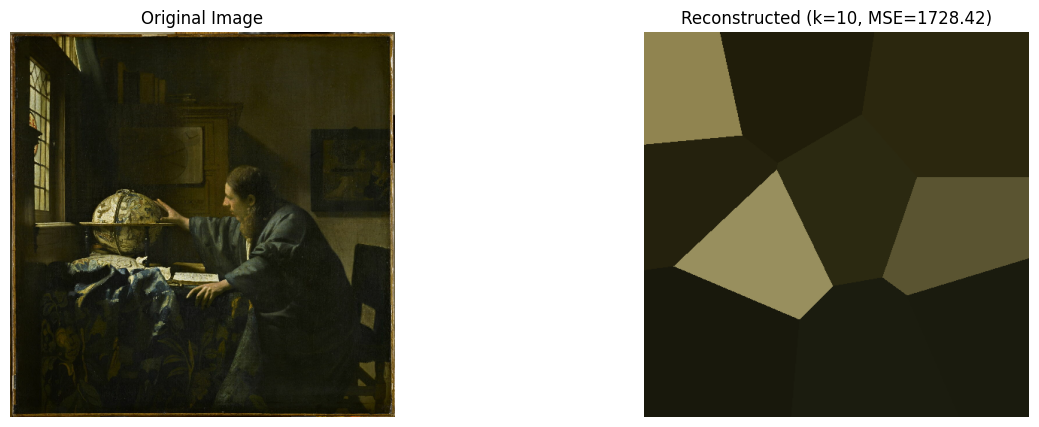

Processing k=50...
MSE for k=50: 1554.68
Compression ratio for k=50: 1429.88


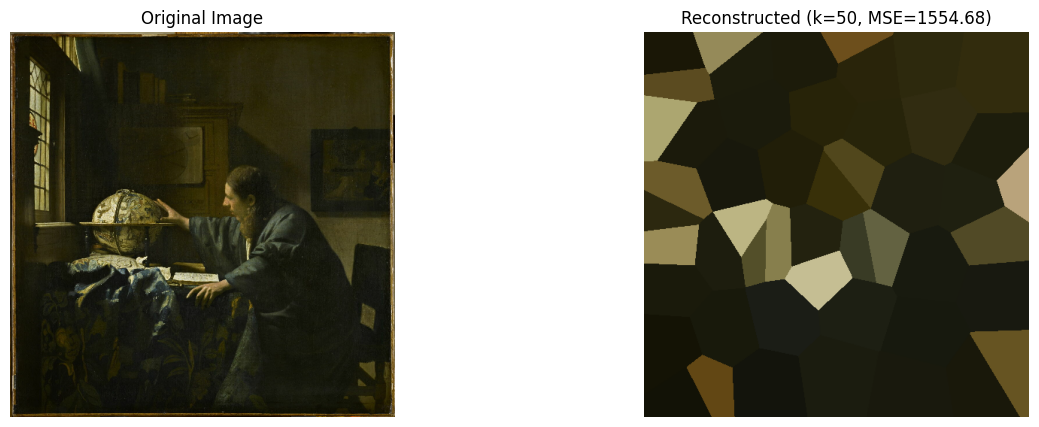

Processing k=100...
MSE for k=100: 1340.60
Compression ratio for k=100: 714.94


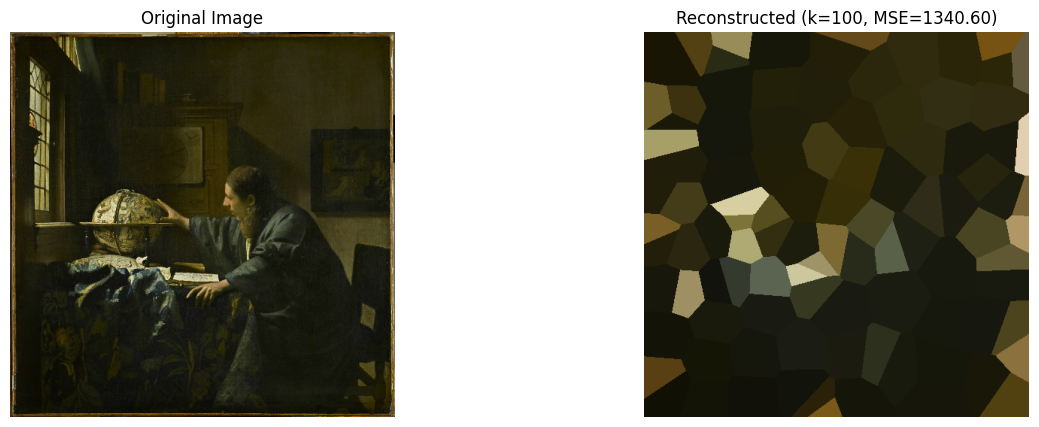

Processing k=1000...
MSE for k=1000: 759.03
Compression ratio for k=1000: 71.49


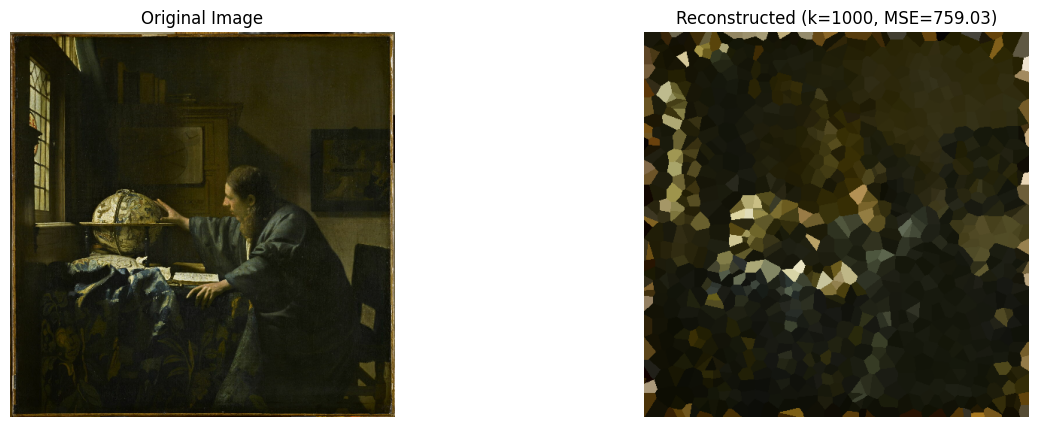

Processing k=5000...
MSE for k=5000: 504.16
Compression ratio for k=5000: 14.30


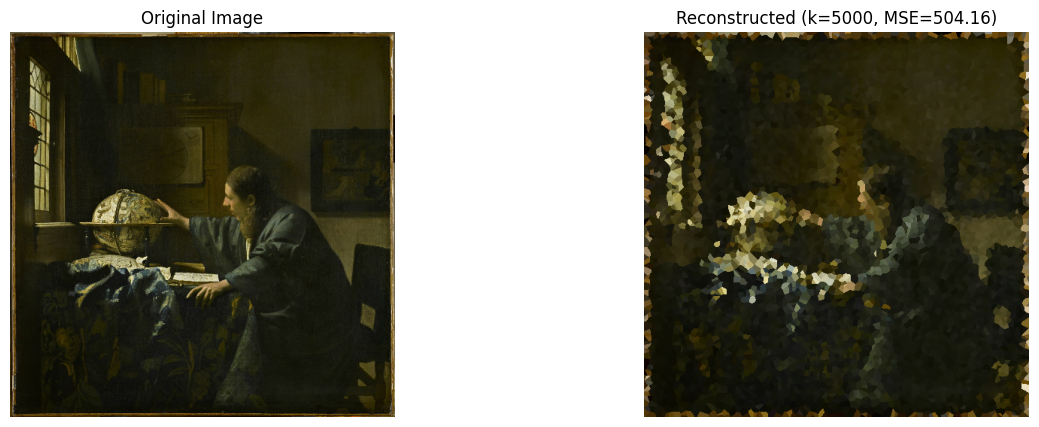

Processing k=10000...
MSE for k=10000: 369.78
Compression ratio for k=10000: 7.15


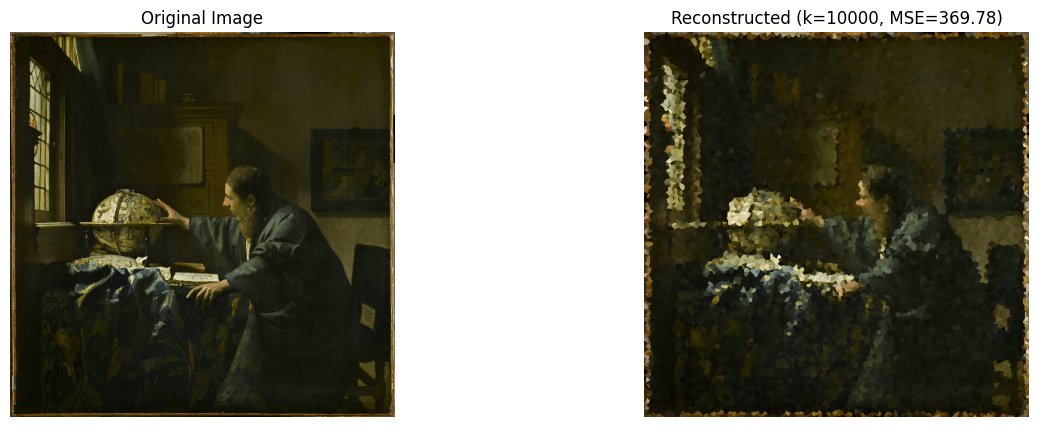

In [15]:
import numpy as np
import cv2
from sklearn.cluster import MiniBatchKMeans
from scipy.spatial import KDTree
import matplotlib.pyplot as plt

# Step 1: Load and preprocess the image
def load_image(image_path):
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Image could not be loaded. Check the file path.")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Resize for efficiency (optional, adjust as needed)
    img = cv2.resize(img, (512, 512))  # Smaller size to speed up processing
    return img

# Step 2: Prepare data for k-means with subsampling
def prepare_data(img, sample_fraction=0.1):
    height, width, _ = img.shape
    x, y = np.meshgrid(np.arange(width), np.arange(height))
    x_norm = x / width
    y_norm = y / height
    colors = img / 255.0
    
    # Flatten and subsample
    data = np.stack([x_norm.ravel(), y_norm.ravel(),
                     colors[:, :, 0].ravel(),
                     colors[:, :, 1].ravel(),
                     colors[:, :, 2].ravel()], axis=1)
    n_samples = int(data.shape[0] * sample_fraction)
    indices = np.random.choice(data.shape[0], n_samples, replace=False)
    sampled_data = data[indices]
    
    return sampled_data, data, height, width

# Step 3: Apply MiniBatchKMeans to find centroids
def compute_centroids(sampled_data, k):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1000, max_iter=100, n_init='auto')
    kmeans.fit(sampled_data)
    centroids = kmeans.cluster_centers_
    return centroids

# Step 4: Reconstruct image using KDTree for Voronoi tessellation
def reconstruct_image(centroids, height, width, full_data):
    # Extract centroid positions and colors
    centroid_positions = centroids[:, :2] * np.array([width, height])
    centroid_colors = centroids[:, 2:] * 255.0
    
    # Use KDTree for fast nearest-neighbor search
    tree = KDTree(centroid_positions)
    coords = full_data[:, :2] * np.array([width, height])  # Full pixel coords
    _, labels = tree.query(coords)
    
    # Reconstruct image
    reconstructed = centroid_colors[labels].reshape(height, width, 3)
    return reconstructed, centroid_positions

# Step 5: Compute MSE
def compute_mse(original, reconstructed):
    return np.mean((original - reconstructed) ** 2)

# Step 6: Visualize the result
def visualize_result(original, reconstructed, centroids, k):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(original.astype(np.uint8))
    plt.title("Original Image")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(reconstructed.astype(np.uint8))
    # plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=10, label='Centroids')
    plt.title(f"Reconstructed (k={k}, MSE={compute_mse(original, reconstructed):.2f})")
    plt.axis('off')
    plt.show()

# Main function
def voronoi_image_compression(image_path, k):
    # Load and preprocess
    img = load_image(image_path)
    sampled_data, full_data, height, width = prepare_data(img, sample_fraction=0.1)
    
    # Compute centroids
    centroids = compute_centroids(sampled_data, k)
    
    # Reconstruct image
    reconstructed, centroid_positions = reconstruct_image(centroids, height, width, full_data)
    
    # Compute MSE and visualize
    mse = compute_mse(img, reconstructed)
    print(f"MSE for k={k}: {mse:.2f}")

    # compute compression ratio
    original_size = img.shape[0] * img.shape[1] * 3
    compressed_size = k * 11
    compression_ratio = original_size / compressed_size
    print(f"Compression ratio for k={k}: {compression_ratio:.2f}")

    visualize_result(img, reconstructed, centroid_positions, k)
    
    return reconstructed, centroid_positions

# Example usage
if __name__ == "__main__":
    image_path = "0000405625_OG.JPG"
    k_values = [10, 50, 100, 1000, 5000, 10000]  # Test with different k values
    
    for k in k_values:
        print(f"Processing k={k}...")
        voronoi_image_compression(image_path, k)